In [11]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [12]:
# Load the data from the uploaded file
with open('../output/experiments/summary.json', 'r') as f:
    summary_data = json.load(f)

In [13]:
# Process the experiments into a tabular format
agg_records = []

for exp in summary_data['experiments']:
    agg_records.append({
        'task': exp['task'],
        'mode': exp['mode'],
        'high_threshold': exp['high_threshold'],
        'medium_threshold': exp['medium_threshold'],
        'n_seeds': exp['n_seeds'],

        'accuracy_mean': exp['accuracy_mean'],
        'accuracy_std': exp['accuracy_std'],

        'macro_f1_mean': exp['macro_f1_mean'],
        'macro_f1_std': exp['macro_f1_std'],

        'micro_f1_mean': exp['micro_f1_mean'],
        'micro_f1_std': exp['micro_f1_std'],

        'weighted_f1_mean': exp['weighted_f1_mean'],
        'weighted_f1_std': exp['weighted_f1_std'],

        'punishment_accuracy_mean': exp.get('punishment_accuracy_mean'),
        'punishment_accuracy_std': exp.get('punishment_accuracy_std'),
    })

# Convert the list of records into a pandas DataFrame
agg_df = pd.DataFrame(agg_records)
agg_df['config_label'] = agg_df.apply(
    lambda r: 'no-rag' if r['mode'] == 'no-rag'
    else f"h{r['high_threshold']}/m{r['medium_threshold']}",
    axis=1
)
agg_df

,task,mode,high_threshold,medium_threshold,n_seeds,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,micro_f1_mean,micro_f1_std,weighted_f1_mean,weighted_f1_std,punishment_accuracy_mean,punishment_accuracy_std,config_label
0,cls,no-rag,-,-,3,0.6581,0.0148,0.3320,0.0259,0.6581,0.0148,0.7000,0.0064,NaN,NaN,no-rag
1,cls,rag,0.85,0.7,3,0.8889,0.0148,0.5953,0.1255,0.8889,0.0148,0.8846,0.0170,NaN,NaN,h0.85/m0.7
2,cls,rag,0.9,0.75,3,0.8803,0.0534,0.5982,0.1652,0.8803,0.0534,0.8807,0.0485,NaN,NaN,h0.9/m0.75
3,cls,rag,0.95,0.8,3,0.8718,0.0513,0.5793,0.1806,0.8718,0.0513,0.8713,0.0508,NaN,NaN,h0.95/m0.8
4,pun,no-rag,-,-,3,0.7284,0.0214,0.2809,0.0048,0.7284,0.0214,0.8428,0.0144,0.6420,0.0855,no-rag
5,pun,rag,0.85,0.7,3,0.9753,0.0428,0.3290,0.0074,0.9753,0.0428,0.9872,0.0222,0.8025,0.1497,h0.85/m0.7
6,pun,rag,0.9,0.75,3,0.9630,0.0371,0.3269,0.0064,0.9630,0.0371,0.9809,0.0193,0.7901,0.1300,h0.9/m0.75
7,pun,rag,0.95,0.8,3,0.9753,0.0428,0.3290,0.0074,0.9753,0.0428,0.9872,0.0222,0.8025,0.1497,h0.95/m0.8


In [14]:
seed_records = []

for exp in summary_data['experiments']:
    for seed_info in exp['per_seed']:
        seed_records.append({
            'task': exp['task'],
            'mode': exp['mode'],
            'high_threshold': exp['high_threshold'],
            'medium_threshold': exp['medium_threshold'],
            'seed': seed_info['seed'],

            'accuracy': seed_info['accuracy'],
            'macro_f1': seed_info['macro_f1'],
            'micro_f1': seed_info['micro_f1'],
            'weighted_f1': seed_info['weighted_f1'],
            'punishment_accuracy': seed_info.get('punishment_accuracy'),

            'source': seed_info['source'],
        })

seed_df = pd.DataFrame(seed_records)
seed_df['config_label'] = seed_df.apply(
    lambda r: 'no-rag' if r['mode'] == 'no-rag'
    else f"h{r['high_threshold']}/m{r['medium_threshold']}",
    axis=1
)
seed_df

,task,mode,high_threshold,medium_threshold,seed,accuracy,macro_f1,micro_f1,weighted_f1,punishment_accuracy,source,config_label
0,cls,no-rag,-,-,42,0.6410,0.3619,0.6410,0.6956,NaN,output/experiments/seed_42/eval_cls_norag_seed...,no-rag
1,cls,no-rag,-,-,43,0.6667,0.3177,0.6667,0.7073,NaN,output/experiments/seed_43/eval_cls_norag_seed...,no-rag
2,cls,no-rag,-,-,44,0.6667,0.3165,0.6667,0.6971,NaN,output/experiments/seed_44/eval_cls_norag_seed...,no-rag
3,cls,rag,0.85,0.7,42,0.8718,0.5226,0.8718,0.8690,NaN,output/experiments/seed_42/eval_cls_rag_h0.85_...,h0.85/m0.7
4,cls,rag,0.85,0.7,43,0.8974,0.7402,0.8974,0.9028,NaN,output/experiments/seed_43/eval_cls_rag_h0.85_...,h0.85/m0.7
5,cls,rag,0.85,0.7,44,0.8974,0.5232,0.8974,0.8821,NaN,output/experiments/seed_44/eval_cls_rag_h0.85_...,h0.85/m0.7
6,cls,rag,0.9,0.75,42,0.8205,0.4838,0.8205,0.8315,NaN,output/experiments/seed_42/eval_cls_rag_h0.9_m...,h0.9/m0.75
7,cls,rag,0.9,0.75,43,0.9231,0.7876,0.9231,0.9285,NaN,output/experiments/seed_43/eval_cls_rag_h0.9_m...,h0.9/m0.75
8,cls,rag,0.9,0.75,44,0.8974,0.5232,0.8974,0.8821,NaN,output/experiments/seed_44/eval_cls_rag_h0.9_m...,h0.9/m0.75
9,cls,rag,0.95,0.8,42,0.8205,0.4838,0.8205,0.8315,NaN,output/experiments/seed_42/eval_cls_rag_h0.95_...,h0.95/m0.8


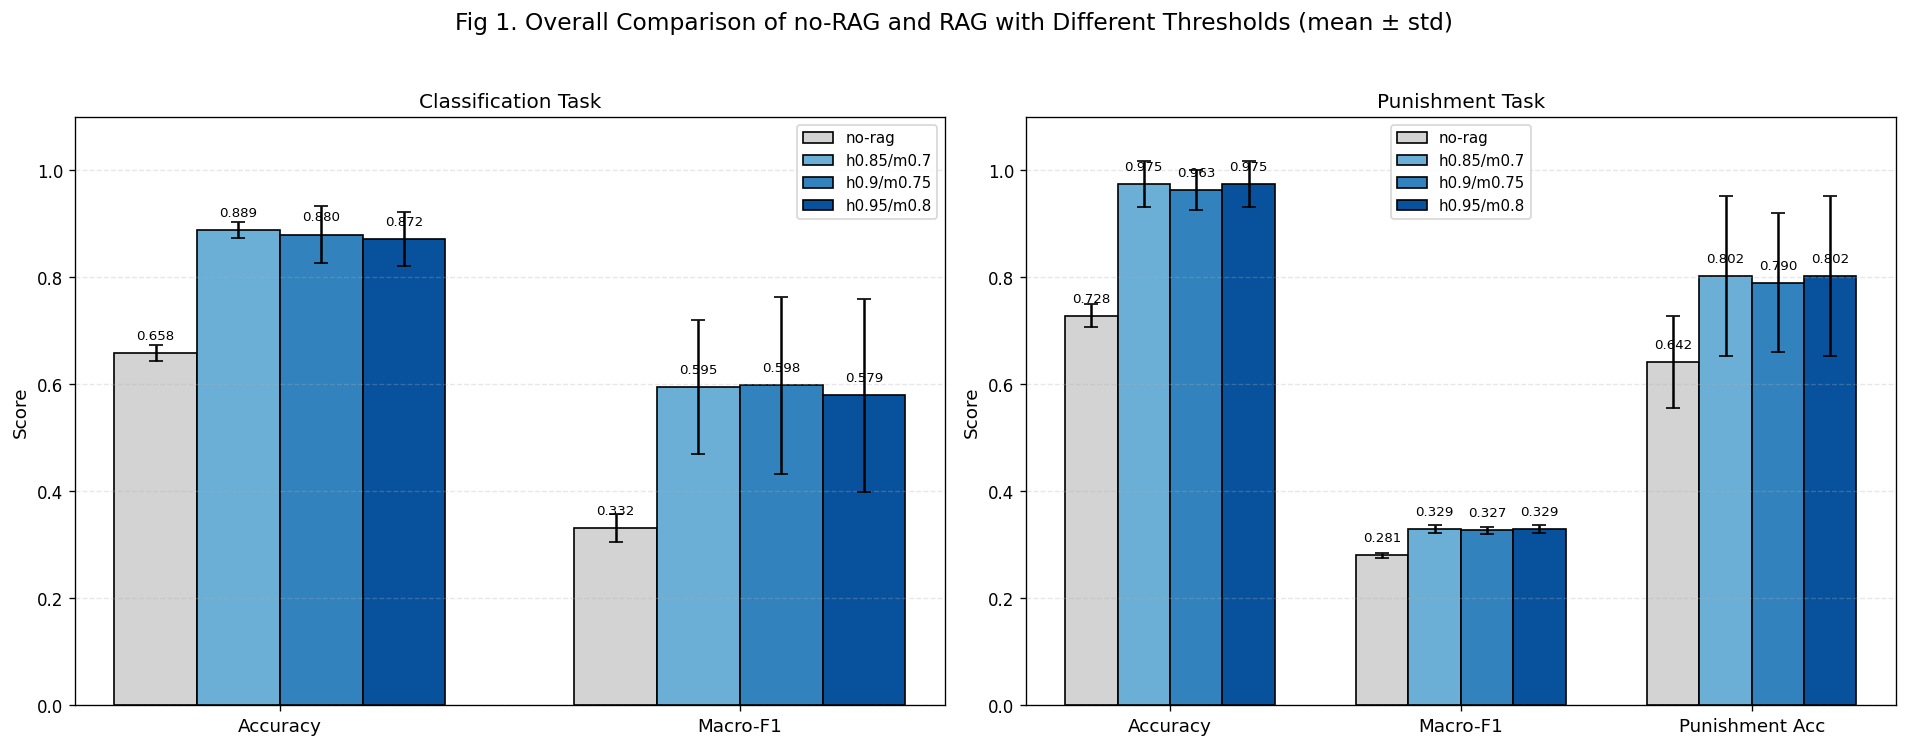

In [15]:
# 图1：RAG vs no-RAG 柱状图
# 固定展示顺序
config_order = [
    ('no-rag', '-', '-'),
    ('rag', '0.85', '0.7'),
    ('rag', '0.9', '0.75'),
    ('rag', '0.95', '0.8')
]

config_labels = [
    'no-rag',
    'h0.85/m0.7',
    'h0.9/m0.75',
    'h0.95/m0.8'
]

config_colors = ['lightgray', '#6baed6', '#3182bd', '#08519c']

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

task_titles = {
    'cls': 'Classification Task',
    'pun': 'Punishment Task'
}

metric_name_map = {
    'accuracy': 'Accuracy',
    'macro_f1': 'Macro-F1',
    'punishment_accuracy': 'Punishment Acc'
}

for ax, task_name in zip(axes, ['cls', 'pun']):
    # cls 和 pun 的指标不同
    if task_name == 'cls':
        metrics = ['accuracy', 'macro_f1']
    else:
        metrics = ['accuracy', 'macro_f1', 'punishment_accuracy']

    x = np.arange(len(metrics))
    width = 0.18

    # 依次画 4 组配置
    for i, ((mode, h, m), label, color) in enumerate(zip(config_order, config_labels, config_colors)):
        if mode == 'no-rag':
            row = agg_df[
                (agg_df['task'] == task_name) &
                (agg_df['mode'] == 'no-rag')
            ].iloc[0]
        else:
            row = agg_df[
                (agg_df['task'] == task_name) &
                (agg_df['mode'] == 'rag') &
                (agg_df['high_threshold'].astype(str) == h) &
                (agg_df['medium_threshold'].astype(str) == m)
            ].iloc[0]

        means = [row[f'{metric}_mean'] for metric in metrics]
        stds = [row[f'{metric}_std'] for metric in metrics]

        # 让 4 根柱子围绕每个 metric 居中排列
        offset = (i - 1.5) * width

        bars = ax.bar(
            x + offset, means, width,
            yerr=stds, capsize=4,
            color=color, edgecolor='black',
            label=label
        )

        # 数值标注
        for b in bars:
            h_val = b.get_height()
            ax.text(
                b.get_x() + b.get_width() / 2,
                h_val + 0.02,
                f'{h_val:.3f}',
                ha='center', va='bottom', fontsize=8
            )

    ax.set_xticks(x)
    ax.set_xticklabels([metric_name_map[m] for m in metrics], fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(task_titles[task_name], fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

fig.suptitle('Fig 1. Overall Comparison of no-RAG and RAG with Different Thresholds (mean ± std)', fontsize=14, y=1.03)
fig.tight_layout()
plt.show()

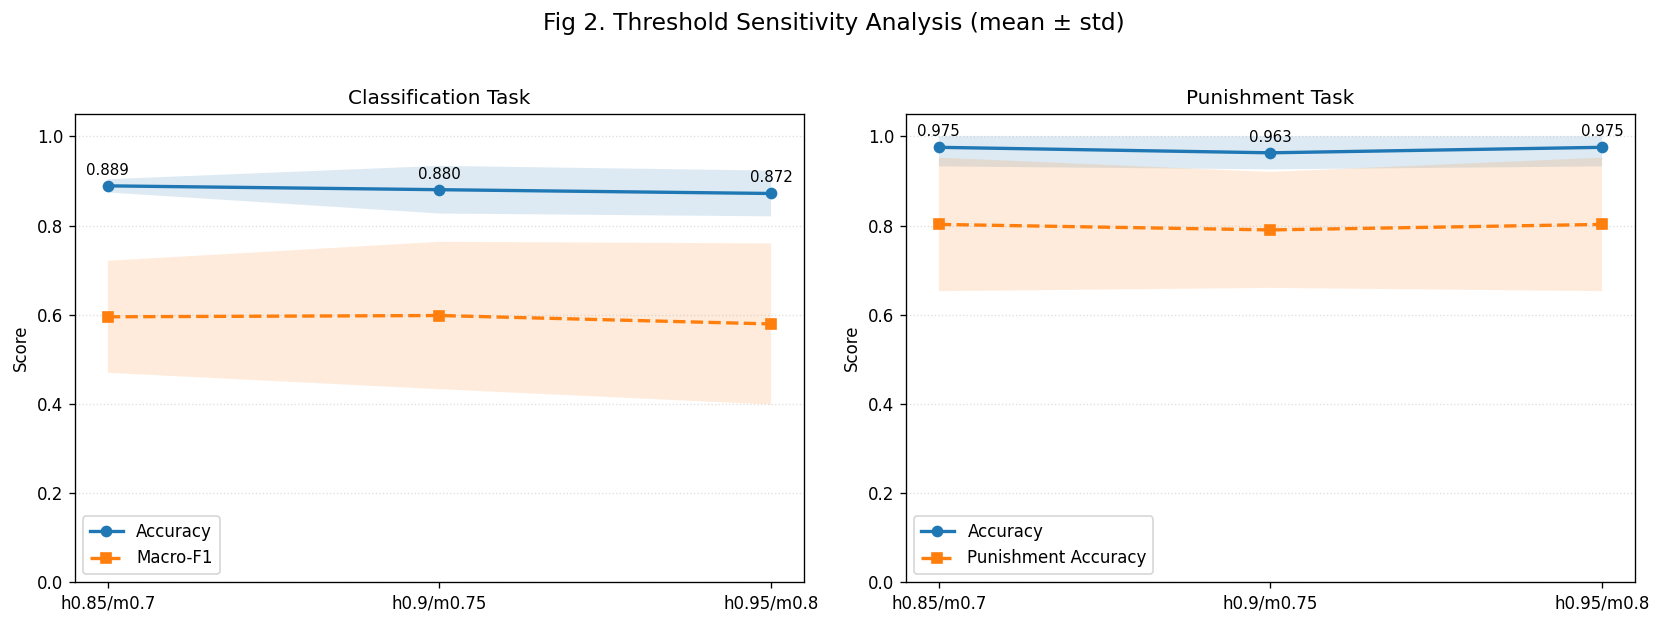

In [16]:
# 图2：阈值敏感性折线图（cls: accuracy + macro_f1；pun: punishment_accuracy + accuracy）

threshold_order = ['h0.85/m0.7', 'h0.9/m0.75', 'h0.95/m0.8']
x = np.arange(len(threshold_order))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

task_titles = {
    'cls': 'Classification Task',
    'pun': 'Punishment Task'
}

for ax, task_name in zip(axes, ['cls', 'pun']):
    sub = agg_df[(agg_df['task'] == task_name) & (agg_df['mode'] == 'rag')].copy()

    # 如果你前面已经有 config_label，这里直接按它重排
    sub = sub.set_index('config_label').loc[threshold_order].reset_index()

    if task_name == 'cls':
        # ===== cls：accuracy + macro_f1 =====
        metric1_mean = sub['accuracy_mean'].values
        metric1_std  = sub['accuracy_std'].values
        metric1_name = 'Accuracy'

        metric2_mean = sub['macro_f1_mean'].values
        metric2_std  = sub['macro_f1_std'].values
        metric2_name = 'Macro-F1'

    else:
        # ===== pun：punishment_accuracy + accuracy =====
        metric2_mean = sub['punishment_accuracy_mean'].values
        metric2_std  = sub['punishment_accuracy_std'].values
        metric2_name = 'Punishment Accuracy'

        metric1_mean = sub['accuracy_mean'].values
        metric1_std  = sub['accuracy_std'].values
        metric1_name = 'Accuracy'

    # 主指标：实线
    ax.plot(
        x, metric1_mean,
        marker='o', linewidth=2, linestyle='-',
        label=metric1_name
    )
    ax.fill_between(
        x,
        np.clip(metric1_mean - metric1_std, 0, 1),
        np.clip(metric1_mean + metric1_std, 0, 1),
        alpha=0.15
    )

    # 次指标：虚线
    ax.plot(
        x, metric2_mean,
        marker='s', linewidth=2, linestyle='--',
        label=metric2_name
    )
    ax.fill_between(
        x,
        np.clip(metric2_mean - metric2_std, 0, 1),
        np.clip(metric2_mean + metric2_std, 0, 1),
        alpha=0.15
    )

    ax.set_xticks(x)
    ax.set_xticklabels(threshold_order)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title(task_titles[task_name])
    ax.legend()
    ax.grid(axis='y', linestyle=':', alpha=0.4)

    # 只标注主指标数值
    for xi, y in zip(x, metric1_mean):
        ax.text(xi, y + 0.025, f'{y:.3f}', ha='center', fontsize=9)

fig.suptitle('Fig 2. Threshold Sensitivity Analysis (mean ± std)', fontsize=14, y=1.03)
fig.tight_layout()
plt.show()

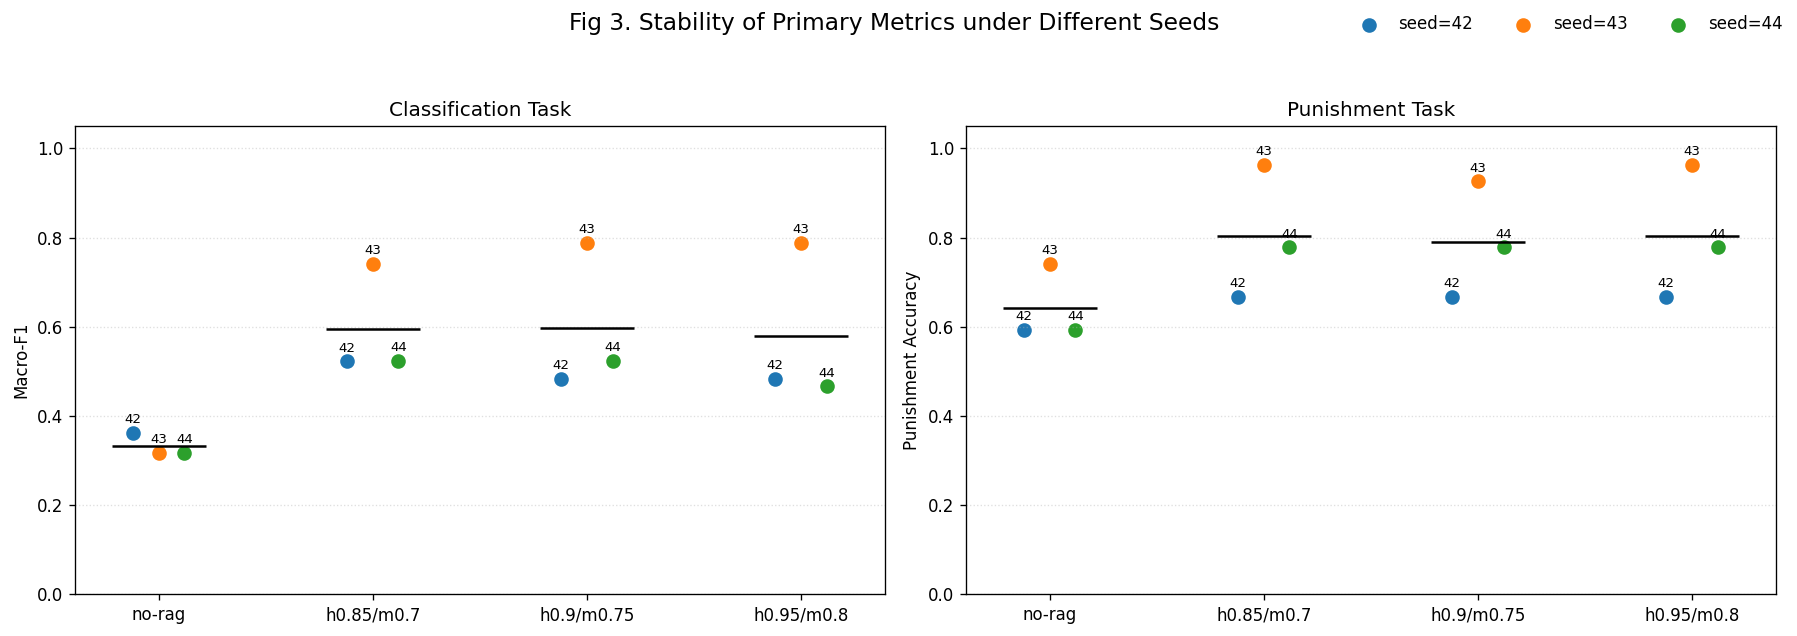

In [17]:
# 图3：per-seed 散点图（cls: Macro-F1；pun: Punishment Accuracy）

fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=120)

task_titles = {'cls': 'Classification Task', 'pun': 'Punishment Task'}
config_order = ['no-rag', 'h0.85/m0.7', 'h0.9/m0.75', 'h0.95/m0.8']
x_pos = {cfg: i for i, cfg in enumerate(config_order)}

# 为不同 seed 加轻微水平偏移，避免重叠
seed_offsets = {42: -0.12, 43: 0.0, 44: 0.12}
seed_colors = {42: 'tab:blue', 43: 'tab:orange', 44: 'tab:green'}

# 每个任务使用的主指标
task_metric = {
    'cls': ('macro_f1', 'macro_f1_mean', 'Macro-F1'),
    'pun': ('punishment_accuracy', 'punishment_accuracy_mean', 'Punishment Accuracy')
}

for ax, task_name in zip(axes, ['cls', 'pun']):
    metric_col, metric_mean_col, metric_label = task_metric[task_name]
    sub = seed_df[seed_df['task'] == task_name].copy()

    for seed in sorted(sub['seed'].unique()):
        seed_sub = sub[sub['seed'] == seed].copy()
        seed_sub = seed_sub.sort_values('config_label')

        xs = [x_pos[cfg] + seed_offsets.get(seed, 0) for cfg in seed_sub['config_label']]
        ys = seed_sub[metric_col].values

        ax.scatter(xs, ys, s=60, color=seed_colors.get(seed, 'gray'), label=f'seed={seed}')

        # 标注 seed 编号
        for x_i, y_i in zip(xs, ys):
            ax.text(x_i, y_i + 0.015, str(seed), ha='center', va='bottom', fontsize=8)

    # 画每个配置的组均值横线
    task_agg = agg_df[agg_df['task'] == task_name].copy().sort_values('config_label')
    for _, row in task_agg.iterrows():
        cfg = row['config_label']
        if pd.isna(cfg):
            continue
        cx = x_pos[str(cfg)]
        mean_y = row[metric_mean_col]
        if not (mean_y != mean_y):  # nan check
            ax.hlines(mean_y, cx - 0.22, cx + 0.22, colors='black', linestyles='-', linewidth=1.5)

    ax.set_xticks(range(len(config_order)))
    ax.set_xticklabels(config_order)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric_label)
    ax.set_title(task_titles[task_name])
    ax.grid(axis='y', linestyle=':', alpha=0.4)

# 统一图例（避免重复）
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=3, frameon=False)

fig.suptitle('Fig 3. Stability of Primary Metrics under Different Seeds', fontsize=14, y=1.05)
fig.tight_layout()
plt.show()

In [18]:
# 主结果对比表：no-rag vs best RAG (h0.9/m0.75)
best_h, best_m = '0.9', '0.75'

def fmt(mean, std):
    if mean is None or (hasattr(mean, '__class__') and mean != mean):  # nan check
        return '-'
    return f"{mean:.4f} ± {std:.4f}"

rows = []
for task in ['cls', 'pun']:
    norag = agg_df[(agg_df['task'] == task) & (agg_df['mode'] == 'no-rag')].iloc[0]
    best  = agg_df[
        (agg_df['task'] == task) &
        (agg_df['mode'] == 'rag') &
        (agg_df['high_threshold'].astype(str) == best_h) &
        (agg_df['medium_threshold'].astype(str) == best_m)
    ].iloc[0]

    row_base = {'Task': task.upper(), 'Config': 'no-rag',
                'Accuracy': fmt(norag['accuracy_mean'], norag['accuracy_std']),
                'Macro-F1': fmt(norag['macro_f1_mean'], norag['macro_f1_std']),
                'Punishment Acc': fmt(norag.get('punishment_accuracy_mean'), norag.get('punishment_accuracy_std'))}
    row_rag  = {'Task': '', 'Config': f'RAG h{best_h}/m{best_m}',
                'Accuracy': fmt(best['accuracy_mean'], best['accuracy_std']),
                'Macro-F1': fmt(best['macro_f1_mean'], best['macro_f1_std']),
                'Punishment Acc': fmt(best.get('punishment_accuracy_mean'), best.get('punishment_accuracy_std'))}
    rows += [row_base, row_rag]

result_df = pd.DataFrame(rows, columns=['Task', 'Config', 'Accuracy', 'Macro-F1', 'Punishment Acc'])
result_df

,Task,Config,Accuracy,Macro-F1,Punishment Acc
0,CLS,no-rag,0.6581 ± 0.0148,0.3320 ± 0.0259,-
1,,RAG h0.9/m0.75,0.8803 ± 0.0534,0.5982 ± 0.1652,-
2,PUN,no-rag,0.7284 ± 0.0214,0.2809 ± 0.0048,0.6420 ± 0.0855
3,,RAG h0.9/m0.75,0.9630 ± 0.0371,0.3269 ± 0.0064,0.7901 ± 0.1300


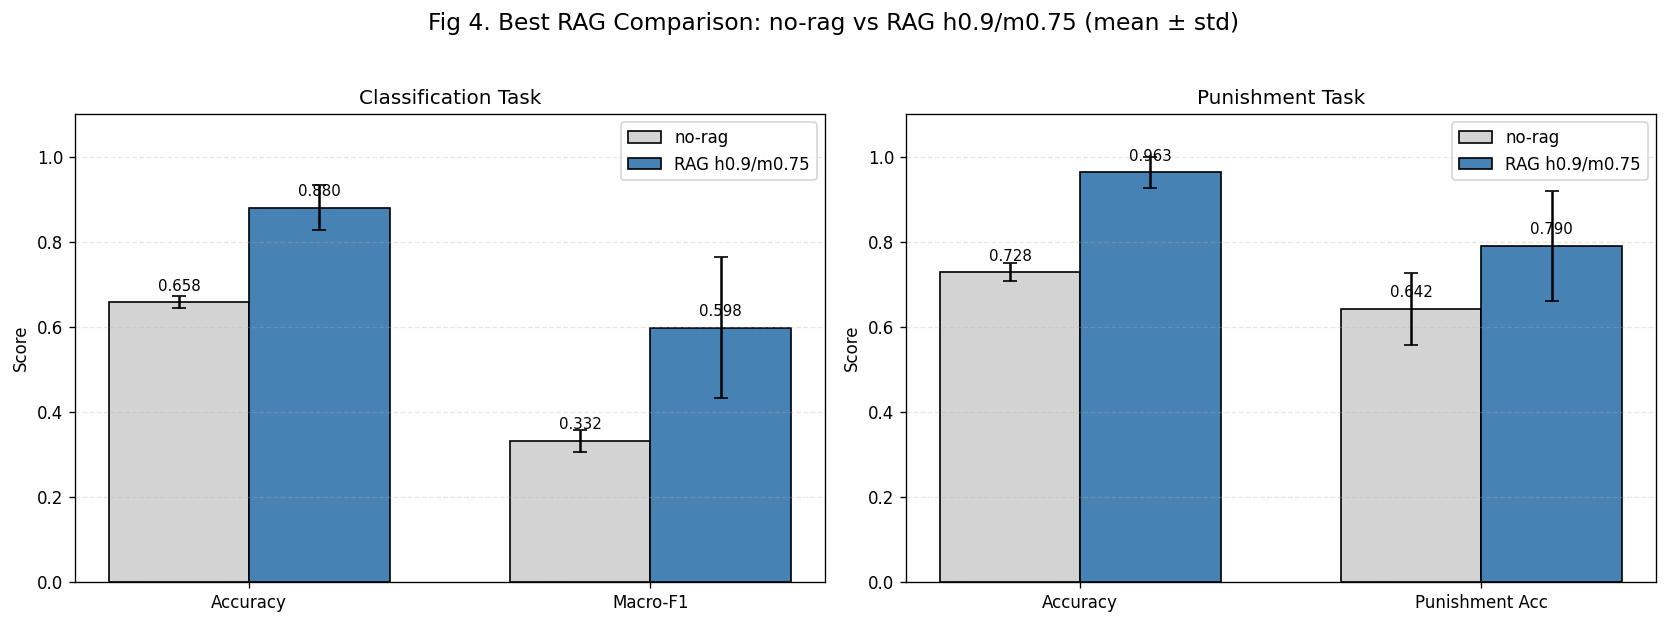

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)
task_titles = {
    'cls': 'Classification Task',
    'pun': 'Punishment Task'
}

metric_labels = {
    'accuracy': 'Accuracy',
    'macro_f1': 'Macro-F1',
    'punishment_accuracy': 'Punishment Acc'
}

for ax, task in zip(axes, ['cls', 'pun']):
    # 取 no-rag 和 best rag
    norag = agg_df[
        (agg_df['task'] == task) & 
        (agg_df['mode'] == 'no-rag')
    ].iloc[0]

    best = agg_df[
        (agg_df['task'] == task) &
        (agg_df['mode'] == 'rag') &
        (agg_df['high_threshold'].astype(str) == best_h) &
        (agg_df['medium_threshold'].astype(str) == best_m)
    ].iloc[0]

    # cls 和 pun 显示的指标不同
    if task == 'cls':
        metrics = ['accuracy', 'macro_f1']
    else:
        metrics = ['accuracy', 'punishment_accuracy']

    x = np.arange(len(metrics))
    width = 0.35

    norag_means = [norag[f'{m}_mean'] for m in metrics]
    norag_stds  = [norag[f'{m}_std'] for m in metrics]

    best_means = [best[f'{m}_mean'] for m in metrics]
    best_stds  = [best[f'{m}_std'] for m in metrics]

    bars1 = ax.bar(
        x - width/2,
        norag_means,
        width,
        yerr=norag_stds,
        capsize=4,
        label='no-rag',
        color='lightgray',
        edgecolor='black'
    )

    bars2 = ax.bar(
        x + width/2,
        best_means,
        width,
        yerr=best_stds,
        capsize=4,
        label=f'RAG h{best_h}/m{best_m}',
        color='steelblue',
        edgecolor='black'
    )

    # 坐标轴设置
    ax.set_xticks(x)
    ax.set_xticklabels([metric_labels[m] for m in metrics])
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.set_title(task_titles[task])
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # 数值标注
    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + 0.02,
                f'{h:.3f}',
                ha='center',
                va='bottom',
                fontsize=9
            )

fig.suptitle(f'Fig 4. Best RAG Comparison: no-rag vs RAG h{best_h}/m{best_m} (mean ± std)', fontsize=14, y=1.03)
fig.tight_layout()
plt.show()

## 实验结论

### 1. RAG 显著提升分类准确率
- **分类任务 (cls)**：RAG (h0.9/m0.75) 将 Accuracy 从 0.6581 提升至 0.8803（**+22.2pp**），Macro-F1 从 0.332 提升至 0.598（**+26.6pp**）。
- **判罚任务 (pun)**：RAG (h0.9/m0.75) 将 Accuracy 从 0.7284 提升至 0.9630（**+23.5pp**），Punishment Accuracy 从 0.642 提升至 0.790（**+14.8pp**）。

### 2. 最优阈值：h0.9 / m0.75
- cls：在三组 RAG 阈值中，h0.85/m0.7 的 Accuracy 最高（0.8889），但 h0.9/m0.75 的 Macro-F1 最高（0.5982），综合考虑类别不平衡问题，**以 Macro-F1 为主要依据**，选择 h0.9/m0.75。
- pun：三组 RAG 阈值 Accuracy 相近，h0.9/m0.75 在 Punishment Accuracy 与稳定性上表现均衡。尽管判罚过程中没有 LLM 调用，但是判罚任务是分类任务的后续，no-rag 在分类任务上表现不佳，导致被漏判的 text 没有处罚结果，使 Punishment Accuracy 降低。

### 3. Macro-F1 偏低的原因
- 数据集类别严重不平衡：绝大多数样本为"不实信息"，"尚无定论"与"确实如此"样本极少。
- pun 任务 Macro-F1 约 0.33。判罚任务的逻辑是检索已有数据的判罚记录，进行近邻投票。在判罚过程中没有 LLM 调用。而判罚数据的dev set 全部来自rumor_weibo，其中全部数据均为"不实信息"，其他两类 support=0，导致 macro 非常低。因此判罚任务应关注 Punishment Accuracy 这一指标。

### 4. 跨 Seed 稳定性
- cls RAG：seed 间准确率波动约 ±5pp，存在一定随机性，需结合均值与标准差解读。
- pun RAG：多组配置下两个 seed 达到 Accuracy=1.0，系统在该任务上具有较高一致性。
